# Real-experiment LMT sequence diagnostics

Runs the sequence from `lmt_real_sequence.build_lmt_real_sequence` (mirroring
`do_clock_interferometry` from `icl_experiments`) on a single cold on-axis atom
and extracts step-by-step diagnostics to help debug the sequence.

**Key plots**
- Sequence event table
- Momentum-class heatmap: probability in each $m$ state after every pulse
- Survival and internal-state fractions vs pulse index
- Phase fringe: $P_e$ vs `phase_step` for an ideal atom


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from tqdm import tqdm

import lmt_simulation as sim
from lmt_real_sequence import (
    build_lmt_real_sequence,
    Clearout as SeqClearout,
    Freefall,
)

plt.rcParams['figure.figsize'] = (12, 5)
%matplotlib inline


## Sequence

In [2]:
N = 7                 # LMT pulses per side (experiment default)
PHASE_STEP = 0.0      # mirror / BS2 phase (rad); set != 0 to check fringe
PRUNE_THRESHOLD = 1e-9  # drop state rows with |amp|^2 below this

sequence = build_lmt_real_sequence(N=N, phase_step=PHASE_STEP)

# ── pretty-print the event table ──────────────────────────────────────
header = f"{'idx':>4}  {'type':>8}  {'t/µs':>8}  {'dur/µs':>8}  "\
         f"{'k':>3}  {'det/δrec':>9}  {'area/π':>7}  label"
print(header)
print('-' * len(header))
for i, ev in enumerate(sequence):
    if isinstance(ev, sim.Pulse):
        det = ev.detuning_hz / sim.RECOIL_FREQUENCY_HZ
        print(f"{i:>4}  {'PULSE':>8}  {ev.time*1e6:>8.1f}  "
              f"{ev.duration*1e6:>8.2f}  {ev.k:>+3}  {det:>+9.2f}  "
              f"{ev.pulse_area/np.pi:>7.3f}  {ev.label}")
    elif isinstance(ev, SeqClearout):
        print(f"{i:>4}  {'CLEAROUT':>8}  {ev.time*1e6:>8.1f}  "
              f"{ev.duration*1e6:>8.1f}  {'':>3}  {'':>9}  {'':>7}  {ev.label}")
    else:
        print(f"{i:>4}  {'FREEFALL':>8}  {ev.time*1e6:>8.1f}  "
              f"{ev.duration*1e6:>8.1f}  {'':>3}  {'':>9}  {'':>7}  {ev.label}")

total_dur = sequence[-1].time + (sequence[-1].duration if hasattr(sequence[-1], 'duration') else 0)
n_pulses = sum(1 for e in sequence if isinstance(e, sim.Pulse))
n_clearouts = sum(1 for e in sequence if isinstance(e, SeqClearout))
print(f'\n{n_pulses} pulses, {n_clearouts} clearouts, total duration {total_dur*1e6:.0f} µs')


 idx      type      t/µs    dur/µs    k   det/δrec   area/π  label
------------------------------------------------------------------
   0     PULSE       0.0    380.00   +1      +1.00    1.000  velocity_selection
   1  CLEAROUT     380.0    2200.0                           vs_clearout
   2  FREEFALL    2580.0    1000.0                           vs_to_bs1
   3     PULSE    3580.0     34.00   -1      +7.00    0.500  BS1
   4  FREEFALL    3614.0     100.0                           post_bs1
   5  FREEFALL    3714.0      50.0                           pre_first_selective_upper
   6     PULSE    3764.0     95.00   +1      +9.00    1.000  first_selective_upper
   7  CLEAROUT    3859.0      50.0                           clearout_after_first_sel_upper
   8  FREEFALL    3909.0      50.0                           lmt_gap
   9     PULSE    3959.0     68.00   -1     +15.00    1.000  upper_fw_0
  10  FREEFALL    4027.0      10.0                           lmt_gap
  11  FREEFALL    4037.0      50.0 

## Detuning check

For each pulse, compare the actual detuning from `build_lmt_real_sequence` against
the resonant detuning expected by `lmt_simulation.py`.

The resonant condition from Borde Eq. 7 (at $v_z = 0$) is:

$$\Delta_{\rm res} = [(m_g + k)^2 - m_g^2]\,\delta_{\rm rec} = (2\,m_g\,k + 1)\,\delta_{\rm rec}$$

This matches `_resonant_detuning` in `lmt_full_sim.ipynb` but **differs** from
the formula `4*m_g + k` used in `lmt_real_sequence.py` whenever $m_g \neq 0$.

In [3]:
# Compare actual vs expected-resonant detunings
# Borde eq. 7 resonance (vz=0): Delta_res = [(m_g+k)^2 - m_g^2]*f_rec = (2*m_g*k+1)*f_rec
# lmt_full_sim.ipynb uses exactly this; lmt_real_sequence.py uses (4*m_g+k)*f_rec.

f_rec = sim.RECOIL_FREQUENCY_HZ

def resonant_det(m_g, k):
    return (2 * m_g * k + 1) * f_rec


print(f"{'idx':>4}  {'label':>35}  {'k':>3}  {'m_g':>5}  "
      f"{'actual/d':>9}  {'expect/d':>9}  {'off/d':>7}  notes")
print('-'*95)

any_mismatch = False
for i, ev in enumerate(sequence):
    if not isinstance(ev, sim.Pulse):
        continue
    det_d = ev.detuning_hz / f_rec           # actual in delta_rec units
    # Invert lmt_real_sequence formula: det_recoil = 4*m_g + k  =>  m_g = (det-k)/4
    m_g_nom = round((det_d - ev.k) / 4.0)
    exp_d = resonant_det(m_g_nom, ev.k) / f_rec
    offset = det_d - exp_d
    flag = '  *** MISMATCH' if abs(offset) > 0.01 else '  ok'
    if abs(offset) > 0.01:
        any_mismatch = True
    print(f"{i:>4}  {ev.label:>35}  {ev.k:>+3}  {m_g_nom:>5d}  "
          f"{det_d:>+9.2f}  {exp_d:>+9.2f}  {offset:>+7.2f} {flag}")

if any_mismatch:
    print()
    print('RESULT: Detuning mismatches found.')
    print('  lmt_real_sequence.py formula: det = (4*m_g + k) * delta_rec')
    print('  Borde resonance (vz=0):        det = (2*m_g*k + 1) * delta_rec')
    print('  These agree only when m_g = 0 or k = 1 and m_g satisfies 2*m_g = 4*m_g => m_g=0.')
    print('  Fix: replace (4*m_g + k) with (2*m_g*k + 1) in lmt_real_sequence.py.')
else:
    print('All detunings match resonant condition.')


 idx                                label    k    m_g   actual/d   expect/d    off/d  notes
-----------------------------------------------------------------------------------------------
   0                   velocity_selection   +1      0      +1.00      +1.00    +0.00   ok
   3                                  BS1   -1      2      +7.00      -3.00   +10.00   *** MISMATCH
   6                first_selective_upper   +1      2      +9.00      +5.00    +4.00   *** MISMATCH
   9                           upper_fw_0   -1      4     +15.00      -7.00   +22.00   *** MISMATCH
  12                           upper_fw_1   +1      4     +17.00      +9.00    +8.00   *** MISMATCH
  15                           upper_fw_2   -1      6     +23.00     -11.00   +34.00   *** MISMATCH
  18                           upper_fw_3   +1      6     +25.00     +13.00   +12.00   *** MISMATCH
  21                           upper_fw_4   -1      8     +31.00     -15.00   +46.00   *** MISMATCH
  25                  

## Step-by-step diagnostics helper

Runs the sequence on a single cold atom with:
- **Deterministic clearouts**: project to the excited branch and renormalise;
  record the surviving probability fraction.
- **Snapshots** after every pulse and every clearout (free-fall gaps only
  affect phases, never populations, so they need no separate snapshot).
- **Pruning**: rows with $|\tilde{c}|^2 <$ `PRUNE_THRESHOLD` are dropped.

In [4]:
def _probs_per_m(m_vals, sq, isg):
    """Dict: m → total probability (ground + excited)."""
    result = {}
    for mv in np.unique(m_vals):
        mask = m_vals == mv
        ag = np.sum(sq[mask & isg])
        ae = np.sum(sq[mask & ~isg])
        result[int(mv)] = float(np.abs(ag)**2 + np.abs(ae)**2)
    return result


def run_diagnostics(sequence, vz0=0.0, prune_threshold=1e-9):
    """
    Run *sequence* deterministically on one cold atom.

    Returns a list of snapshot dicts (one per pulse or clearout) with keys:
      label, event_type, n_rows, p_norm, p_ground, p_excited,
      p_surviving, probs_per_m
    """
    first_pulse = next(e for e in sequence if isinstance(e, sim.Pulse))
    omega_laser = 2 * np.pi * (sim.TRANSITION_FREQUENCY + first_pulse.detuning_hz)

    m, pos, vel, amp, isg = sim.make_atom_states(
        initial_velocity_z=vz0, c0=1.0, c1=0.0
    )
    sq = sim.transform_state_vector(
        m, amp, isg, omega_laser=omega_laser, t=0.0, z=0.0, vz=vz0, inverse=False
    )

    snapshots = []
    p_surviving = 1.0

    def snap(label, m, sq, isg, etype):
        pg = float(np.sum(np.abs(sq[isg])**2))
        pe = float(np.sum(np.abs(sq[~isg])**2))
        snapshots.append(dict(
            label=label, event_type=etype,
            n_rows=len(m), p_norm=pg+pe,
            p_ground=pg, p_excited=pe,
            p_surviving=p_surviving,
            probs_per_m=_probs_per_m(m, sq, isg),
        ))

    snap('initial', m, sq, isg, 'init')

    for ev in sequence:
        if isinstance(ev, sim.Pulse):
            omega_laser = 2 * np.pi * (sim.TRANSITION_FREQUENCY + ev.detuning_hz)
            m, sq, isg, pos, vel = sim.pulse_interaction_in_borde_representation(
                m, sq, isg, pos, vel,
                pulse_detuning=ev.detuning_hz,
                t_pulse=ev.duration,
                pulse_rabi_freq=ev.rabi_frequency,
                pulse_phase=ev.phi,
                k_sign=ev.k,
                vz=vz0,
            )
            keep = np.abs(sq)**2 > prune_threshold
            if not keep.any():
                break
            m, sq, isg, pos, vel = m[keep], sq[keep], isg[keep], pos[keep], vel[keep]
            snap(ev.label, m, sq, isg, 'pulse')

        elif isinstance(ev, SeqClearout):
            exc_mask = ~isg
            p_exc = float(np.sum(np.abs(sq[exc_mask])**2))
            if p_exc < 1e-12:
                snap(ev.label + ' [LOST ALL]', m, sq, isg, 'clearout')
                break
            p_surviving *= p_exc
            sq = sq[exc_mask] / np.sqrt(p_exc)
            m, isg, pos, vel = m[exc_mask], isg[exc_mask], pos[exc_mask], vel[exc_mask]
            snap(ev.label, m, sq, isg, 'clearout')

        elif isinstance(ev, Freefall):
            # Populations unchanged; only phases evolve.
            m, sq, isg, pos, vel = sim.propagate_states_in_borde_representation(
                m, sq, isg, pos, vel,
                time_of_propegation=ev.duration,
                omega_laser=omega_laser,
                vz=vz0, k_sign=+1,
            )

    return snapshots


## Run (cold on-axis atom)

In [5]:
snaps = run_diagnostics(sequence, vz0=0.0, prune_threshold=PRUNE_THRESHOLD)

print(f"{'idx':>4}  {'type':>8}  {'rows':>5}  {'P_gnd':>7}  {'P_exc':>7}  "
      f"{'P_surv':>8}  label")
print('-'*80)
for i, s in enumerate(snaps):
    print(f"{i:>4}  {s['event_type']:>8}  {s['n_rows']:>5}  "
          f"{s['p_ground']:>7.4f}  {s['p_excited']:>7.4f}  "
          f"{s['p_surviving']:>8.4f}  {s['label']}")


 idx      type   rows    P_gnd    P_exc    P_surv  label
--------------------------------------------------------------------------------
   0      init      2   1.0000   0.0000    1.0000  initial
   1     pulse      1   0.0000   1.0000    1.0000  velocity_selection
   2  clearout      1   0.0000   1.0000    1.0000  vs_clearout
   3     pulse      2   0.0206   0.9794    1.0000  BS1
   4     pulse      4   0.0369   0.9631    1.0000  first_selective_upper
   5  clearout      2   0.0000   1.0000    0.9631  clearout_after_first_sel_upper
   6     pulse      4   0.0030   0.9970    0.9631  upper_fw_0
   7     pulse      7   0.0068   0.9932    0.9631  upper_fw_1
   8     pulse     13   0.0095   0.9905    0.9631  upper_fw_2
   9     pulse     23   0.0123   0.9877    0.9631  upper_fw_3
  10     pulse     35   0.0125   0.9875    0.9631  upper_fw_4
  11     pulse     50   0.0127   0.9873    0.9631  upper_rv_0
  12     pulse     75   0.0155   0.9845    0.9631  upper_rv_1
  13     pulse    107   0.

## Momentum-class heatmap

Each column is one pulse or clearout snapshot. Colour encodes the probability
$|c_m|^2$ (scaled by the cumulative survival fraction so clearout losses are visible).
The y-axis is the momentum quantum number $m$.

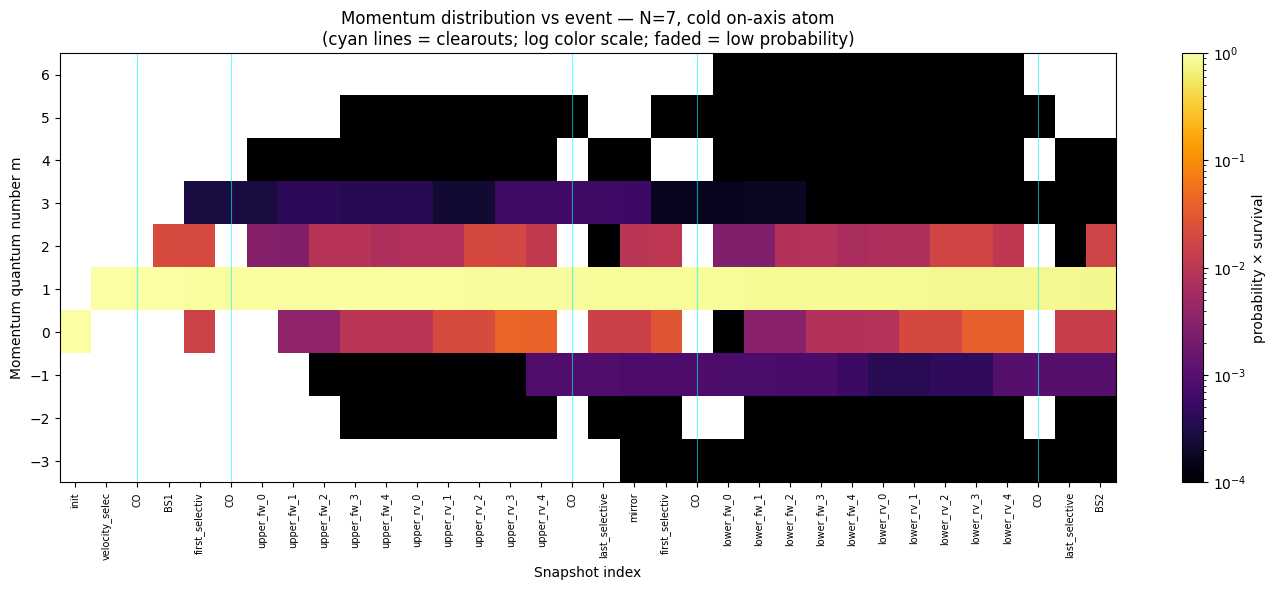

In [6]:
# Collect all m values seen across all snapshots
all_m = sorted({m for s in snaps for m in s['probs_per_m']})
m_to_row = {m: i for i, m in enumerate(all_m)}

# Build matrix: [m_index, snap_index] -> weighted probability
mat = np.zeros((len(all_m), len(snaps)))
for j, s in enumerate(snaps):
    for mv, prob in s['probs_per_m'].items():
        mat[m_to_row[mv], j] = prob * s['p_surviving']

# X-axis labels: shorten pulse labels for readability
def short_label(s):
    lbl = s['label']
    if s['event_type'] == 'clearout': return 'CO'
    if s['event_type'] == 'init':     return 'init'
    # strip common prefix tokens
    for prefix in ('velocity_selection', 'BS1', 'BS2', 'mirror',
                   'first_selective_upper', 'first_selective_lower',
                   'last_selective_upper',  'last_selective_lower'):
        if lbl.startswith(prefix): return lbl[:14]
    return lbl[:10]

xlabels = [short_label(s) for s in snaps]

fig, ax = plt.subplots(figsize=(max(14, len(snaps)*0.35), 6))
im = ax.imshow(
    mat, aspect='auto', origin='lower',
    norm=mcolors.LogNorm(vmin=1e-4, vmax=1.0),
    cmap='inferno',
    extent=[-0.5, len(snaps)-0.5, all_m[0]-0.5, all_m[-1]+0.5],
)
plt.colorbar(im, ax=ax, label='probability × survival')

# Mark clearout columns
for j, s in enumerate(snaps):
    if s['event_type'] == 'clearout':
        ax.axvline(j, color='cyan', lw=0.8, alpha=0.6)

ax.set_xlabel('Snapshot index')
ax.set_ylabel('Momentum quantum number m')
ax.set_yticks(all_m)
ax.set_title(
    f'Momentum distribution vs event — N={N}, cold on-axis atom\n'
    f'(cyan lines = clearouts; log color scale; faded = low probability)'
)
ax.set_xticks(range(len(snaps)))
ax.set_xticklabels(xlabels, rotation=90, fontsize=7)
fig.tight_layout()


## Survival fraction and internal-state populations

- **Top panel**: cumulative survival fraction (product of all clearout probabilities
  up to each snapshot). Drops only at clearouts; flat between them.
- **Bottom panel**: ground and excited probability in the renormalised wavefunction
  (after each clearout the surviving state is renormalised to 1).

Expect: after vel-sel π pulse → P_exc ≈ 1; after BS1 π/2 → P_gnd = P_exc = 0.5; after each selective π → P_exc ≈ 1.

Final snapshot: P_exc=0.9629, P_gnd=0.0371, survival=0.8763
Final m values present: [-3, -2, -1, 0, 1, 2, 3, 4]
  m=-3: 0.00000
  m=-2: 0.00001
  m=-1: 0.00116
  m=+0: 0.01578
  m=+1: 0.90261
  m=+2: 0.01895
  m=+3: 0.00011
  m=+4: 0.00001


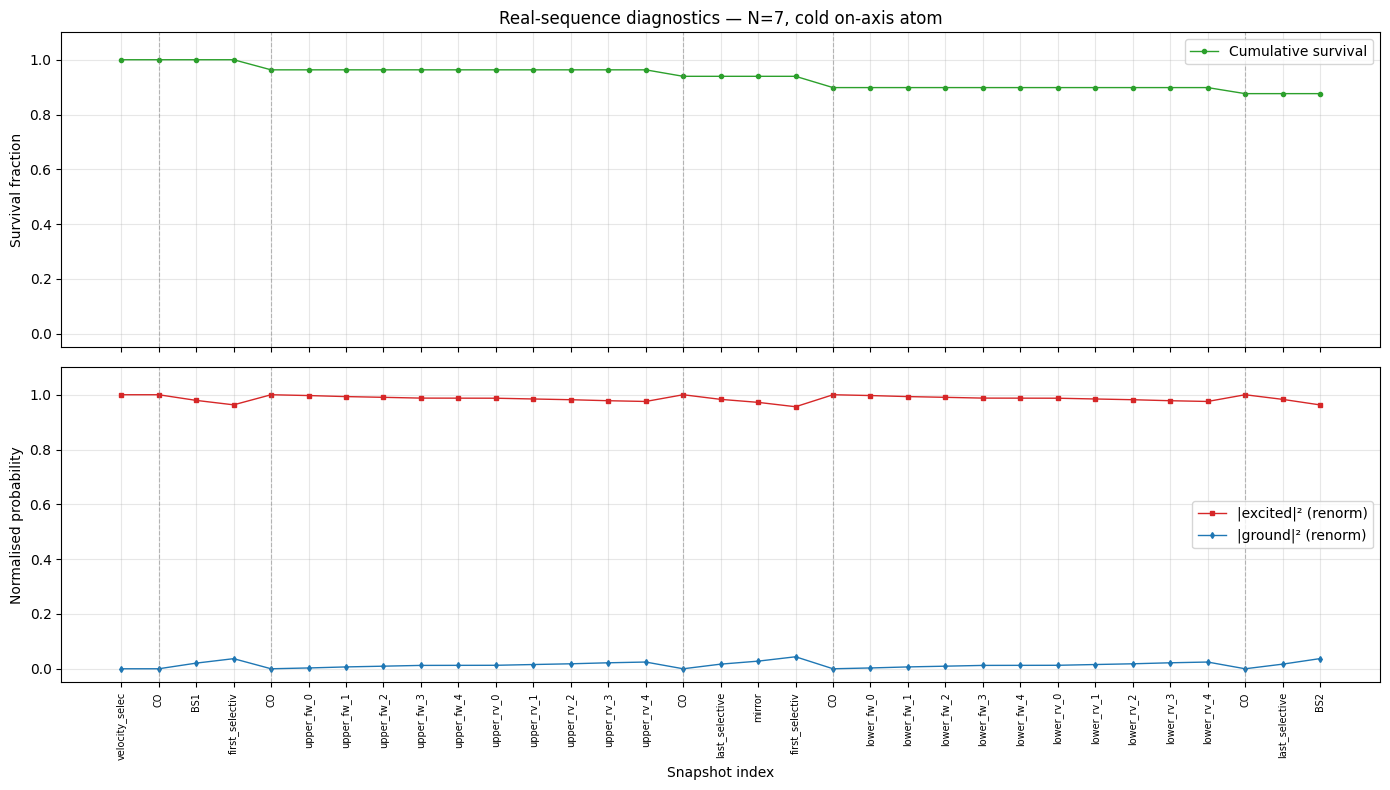

In [7]:
pulse_snaps  = [(i, s) for i, s in enumerate(snaps) if s['event_type'] != 'init']
xs           = [i for i, _ in pulse_snaps]
p_surv       = [s['p_surviving']  for _, s in pulse_snaps]
p_exc_norm   = [s['p_excited']    for _, s in pulse_snaps]
p_gnd_norm   = [s['p_ground']     for _, s in pulse_snaps]
event_types  = [s['event_type']   for _, s in pulse_snaps]
labels_short = [xlabels[i]        for i, _ in pulse_snaps]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(max(14, len(xs)*0.3), 8), sharex=True)

ax1.plot(xs, p_surv, 'o-', color='tab:green', ms=3, lw=1, label='Cumulative survival')
ax1.set_ylabel('Survival fraction')
ax1.set_ylim(-0.05, 1.1)
ax1.set_title(f'Real-sequence diagnostics — N={N}, cold on-axis atom')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(xs, p_exc_norm, 's-', color='tab:red',  ms=3, lw=1, label='|excited|² (renorm)')
ax2.plot(xs, p_gnd_norm, 'd-', color='tab:blue', ms=3, lw=1, label='|ground|² (renorm)')

# Shade clearout positions
for i, s in enumerate(snaps):
    if s['event_type'] == 'clearout':
        ax2.axvline(i, color='gray', lw=0.8, alpha=0.5, linestyle='--')
        ax1.axvline(i, color='gray', lw=0.8, alpha=0.5, linestyle='--')

ax2.set_ylabel('Normalised probability')
ax2.set_ylim(-0.05, 1.1)
ax2.set_xlabel('Snapshot index')
ax2.grid(True, alpha=0.3)
ax2.legend()

ax2.set_xticks(xs)
ax2.set_xticklabels(labels_short, rotation=90, fontsize=7)
fig.tight_layout()

# Print summary
final = snaps[-1]
print(f'Final snapshot: P_exc={final["p_excited"]:.4f}, '
      f'P_gnd={final["p_ground"]:.4f}, survival={final["p_surviving"]:.4f}')
print(f'Final m values present: {sorted(final["probs_per_m"].keys())}')
for mv, pr in sorted(final['probs_per_m'].items()):
    print(f'  m={mv:+d}: {pr:.5f}')


## Dominant momentum class vs event index

Shows the m value carrying the most probability at each snapshot.
Useful for checking the momentum ladder is climbed and descended correctly.

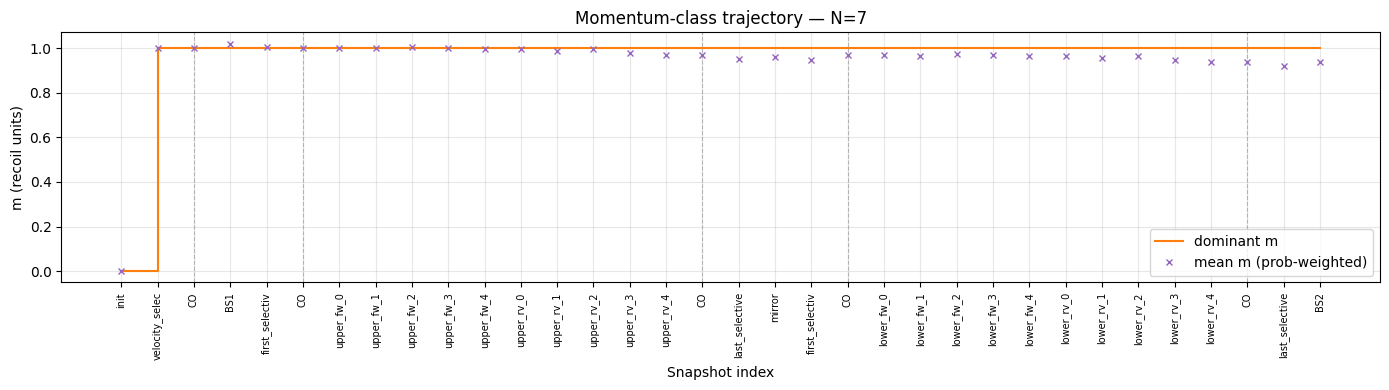

In [8]:
dominant_m = []
mean_m = []
for s in snaps:
    if s['probs_per_m']:
        dm = max(s['probs_per_m'], key=s['probs_per_m'].get)
        mm = sum(k * v for k, v in s['probs_per_m'].items()) / (s['p_norm'] + 1e-30)
    else:
        dm = 0; mm = 0
    dominant_m.append(dm)
    mean_m.append(mm)

fig, ax = plt.subplots(figsize=(max(14, len(snaps)*0.35), 4))
ax.step(range(len(snaps)), dominant_m, where='post', color='tab:orange',
        lw=1.5, label='dominant m')
ax.plot(range(len(snaps)), mean_m, 'x', color='tab:purple',
        ms=4, label='mean m (prob-weighted)')
for i, s in enumerate(snaps):
    if s['event_type'] == 'clearout':
        ax.axvline(i, color='gray', lw=0.8, alpha=0.5, linestyle='--')
ax.set_xlabel('Snapshot index')
ax.set_ylabel('m (recoil units)')
ax.set_title(f'Momentum-class trajectory — N={N}')
ax.set_xticks(range(len(snaps)))
ax.set_xticklabels(xlabels, rotation=90, fontsize=7)
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()


## Phase fringe

Scans `phase_step` from $0$ to $2\pi$ and measures the final excited-state
probability $P_e$ for a single cold on-axis atom.

Uses deterministic clearouts (no MC noise) so a single atom is enough to
trace the full fringe. A clean sinusoid indicates the interferometer closes
correctly; deviations point to systematic phase or amplitude errors.

In [9]:
def run_one_phase(phase_step, vz0=0.0, prune_threshold=1e-9):
    """
    Run the full sequence at the given phase_step.
    Uses deterministic clearout (project to excited, renorm).
    Returns (P_g, P_e, survival) or None if atom lost.
    """
    seq = build_lmt_real_sequence(N=N, phase_step=phase_step)
    first_pulse = next(e for e in seq if isinstance(e, sim.Pulse))
    omega_laser = 2 * np.pi * (sim.TRANSITION_FREQUENCY + first_pulse.detuning_hz)

    m, pos, vel, amp, isg = sim.make_atom_states(
        initial_velocity_z=vz0, c0=1.0, c1=0.0
    )
    sq = sim.transform_state_vector(
        m, amp, isg, omega_laser=omega_laser, t=0.0, z=0.0, vz=vz0, inverse=False
    )
    survival = 1.0

    for ev in seq:
        if isinstance(ev, sim.Pulse):
            omega_laser = 2 * np.pi * (sim.TRANSITION_FREQUENCY + ev.detuning_hz)
            m, sq, isg, pos, vel = sim.pulse_interaction_in_borde_representation(
                m, sq, isg, pos, vel,
                pulse_detuning=ev.detuning_hz,
                t_pulse=ev.duration,
                pulse_rabi_freq=ev.rabi_frequency,
                pulse_phase=ev.phi,
                k_sign=ev.k,
                vz=vz0,
            )
            keep = np.abs(sq)**2 > prune_threshold
            if not keep.any(): return None
            m, sq, isg, pos, vel = m[keep], sq[keep], isg[keep], pos[keep], vel[keep]

        elif isinstance(ev, SeqClearout):
            exc_mask = ~isg
            p_exc = float(np.sum(np.abs(sq[exc_mask])**2))
            if p_exc < 1e-12: return None
            survival *= p_exc
            sq = sq[exc_mask] / np.sqrt(p_exc)
            m, isg, pos, vel = m[exc_mask], isg[exc_mask], pos[exc_mask], vel[exc_mask]

        elif isinstance(ev, Freefall):
            m, sq, isg, pos, vel = sim.propagate_states_in_borde_representation(
                m, sq, isg, pos, vel,
                time_of_propegation=ev.duration,
                omega_laser=omega_laser,
                vz=vz0, k_sign=+1,
            )

    pg, pe = sim.calculate_ground_and_excited_probabilities(m, sq, isg)
    return pg, pe, survival


N_PHASE = 32
phase_values = np.linspace(0, 2 * np.pi, N_PHASE, endpoint=False)

results = [run_one_phase(phi) for phi in tqdm(phase_values, desc='Phase scan')]

pe_vals      = np.array([r[1]        if r else np.nan for r in results])
pg_vals      = np.array([r[0]        if r else np.nan for r in results])
surv_vals    = np.array([r[2]        if r else 0.0    for r in results])

n_lost = sum(1 for r in results if r is None)
print(f'{N_PHASE - n_lost}/{N_PHASE} phase points survived all clearouts')
print(f'Mean survival fraction: {np.nanmean(surv_vals):.4f}')
print(f'P_e range: [{np.nanmin(pe_vals):.4f}, {np.nanmax(pe_vals):.4f}]')
fringe_amp = np.nanmax(pe_vals) - np.nanmin(pe_vals)
fringe_offset = 0.5 * (np.nanmax(pe_vals) + np.nanmin(pe_vals))
contrast = fringe_amp / (2 * fringe_offset) if fringe_offset > 0 else 0
print(f'Fringe amplitude: {fringe_amp:.4f}')
print(f'Michelson contrast: {contrast:.4f}')


Phase scan:   0%|          | 0/32 [00:00<?, ?it/s]

Phase scan:   3%|▎         | 1/32 [00:00<00:11,  2.70it/s]

Phase scan:   6%|▋         | 2/32 [00:00<00:10,  2.91it/s]

Phase scan:   9%|▉         | 3/32 [00:01<00:09,  2.90it/s]

Phase scan:  12%|█▎        | 4/32 [00:01<00:09,  2.83it/s]

...

Phase scan:  94%|█████████▍| 30/32 [00:09<00:00,  3.17it/s]

Phase scan:  97%|█████████▋| 31/32 [00:10<00:00,  3.14it/s]

Phase scan: 100%|██████████| 32/32 [00:10<00:00,  3.09it/s]

Phase scan: 100%|██████████| 32/32 [00:10<00:00,  3.03it/s]

32/32 phase points survived all clearouts
Mean survival fraction: 0.8763
P_e range: [0.9014, 0.9086]
Fringe amplitude: 0.0072
Michelson contrast: 0.0040


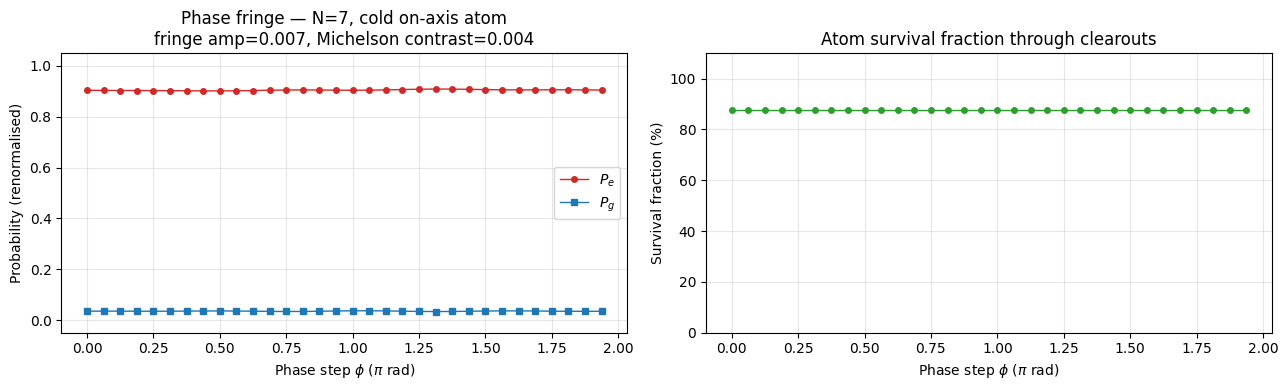

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(phase_values / np.pi, pe_vals, 'o-', color='tab:red',
         ms=4, lw=1, label=r'$P_e$')
ax1.plot(phase_values / np.pi, pg_vals, 's-', color='tab:blue',
         ms=4, lw=1, label=r'$P_g$')
ax1.set_xlabel(r'Phase step $\phi$ ($\pi$ rad)')
ax1.set_ylabel('Probability (renormalised)')
ax1.set_title(
    f'Phase fringe — N={N}, cold on-axis atom\n'
    f'fringe amp={fringe_amp:.3f}, Michelson contrast={contrast:.3f}'
)
ax1.set_ylim(-0.05, 1.05)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(phase_values / np.pi, surv_vals * 100, 'o-', color='tab:green', ms=4, lw=1)
ax2.set_xlabel(r'Phase step $\phi$ ($\pi$ rad)')
ax2.set_ylabel('Survival fraction (%)')
ax2.set_title('Atom survival fraction through clearouts')
ax2.set_ylim(0, 110)
ax2.grid(True, alpha=0.3)

fig.tight_layout()


## Normalization check

Verifies that the total probability is conserved through all pulses
(should stay at 1.0 within floating-point tolerance).
Large deviations indicate a bug in the pulse application.

In [11]:
pulse_only = [(i, s) for i, s in enumerate(snaps) if s['event_type'] == 'pulse']
norm_devs = [abs(s['p_norm'] - 1.0) for _, s in pulse_only]
if norm_devs:
    print(f'Max normalization deviation across all pulses: {max(norm_devs):.2e}')
    bad = [(snaps[i]['label'], abs(s['p_norm']-1)) for i, s in pulse_only
           if abs(s['p_norm']-1) > 1e-6]
    if bad:
        print('Pulses with |P_total - 1| > 1e-6:')
        for lbl, dev in bad:
            print(f'  {lbl}: deviation = {dev:.2e}')
    else:
        print('All pulses conserve probability to within 1e-6. ✓')
else:
    print('No pulse snapshots found.')


Max normalization deviation across all pulses: 2.11e-07
All pulses conserve probability to within 1e-6. ✓
